<a href="https://github.com/Lexsi-Labs/aligntune" target="_blank">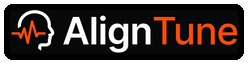</a><a href="https://discord.com/invite/dtEDQ2Z3eg" target="_blank">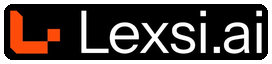</a>


# SDFT — Self-Distillation Fine-Tuning

Fine-tunes a model using its own base weights as the teacher. The model generates completions from a frozen snapshot of itself (`teacher_model_kind='base'`), then trains on those completions. No external teacher model is needed.


## 1  Install AlignTune

Installs AlignTune from PyPI. Safe to re-run; skip if it's already installed.


In [ ]:
# Install AlignTune. Safe to re-run; no runtime restart needed.
!pip install -q aligntune

import aligntune
print("AlignTune", aligntune.__version__, "ready")


## 2  Environment & imports

Quiets logging noise, logs into the Hugging Face Hub, and checks that a GPU is available.


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_EXPERIMENTAL_WARNING"] = "1"

from huggingface_hub import login
try:
    from google.colab import userdata
    _tok = userdata.get("HF_TOKEN")
    if _tok:
        os.environ["HF_TOKEN"] = _tok
except Exception:
    pass

if os.environ.get("HF_TOKEN"):
    login(token=os.environ["HF_TOKEN"])
    print("HF login ok")
else:
    print("No HF_TOKEN secret — public models download fine, gated models won't")

import torch
if not torch.cuda.is_available():
    raise RuntimeError("No GPU found. Runtime → Change runtime type → T4 GPU")
print("GPU:", torch.cuda.get_device_name(0))
_free, _total = torch.cuda.mem_get_info()
print(f"VRAM total:     {_total / 1024**3:.2f} GB")
print(f"VRAM available: {_free / 1024**3:.2f} GB")


## 3  Import trainers

In [ ]:
from aligntune.core.backend_factory import (
    create_sft_trainer,
    create_rl_trainer,
    create_distill_trainer,
    create_es_trainer,
    create_raft_trainer,
)
print("trainers imported")

## 4  Config

These are the only variables you need to change to use your own model or dataset. Everything else in the train cell references these.

In [ ]:
MODEL    = "Qwen/Qwen2.5-0.5B-Instruct"
DATASET  = "tatsu-lab/alpaca"
BACKEND  = "trl"
OUT_DIR  = "./out_sdft"

MAX_SEQ_LEN     = 128
BATCH_SIZE      = 1
LR              = 5e-5
MAX_SAMPLES     = 64  # uncomment to limit dataset size
# MAX_STEPS       = 10  # uncomment for quick debug runs
SEED            = 42
NUM_EPOCHS      = 1
NUM_GENERATIONS = 1    # SDFT samples this many completions from the frozen base teacher
MAX_COMPLETION_LENGTH = 64
LORA_R          = 8
LORA_ALPHA      = 16
LORA_DROPOUT    = 0.0
LORA_BIAS       = "none"
USE_RSLORA      = False
LOFTQ_INIT      = False
GRAD_ACCUM      = 4
WARMUP_RATIO    = 0.03
WEIGHT_DECAY    = 0.01
LR_SCHEDULER    = "linear"

# ── optimizer / schedule / memory (TRL + Unsloth compatible) ──────────────
LORA_TARGETS     = None          # None = AlignTune default attn modules
PISSA_INIT       = False
OPTIMIZER        = "adamw_torch" # adamw_torch | adamw_8bit | sgd | adafactor
MAX_GRAD_NORM    = 1.0
# WARMUP_STEPS   = 0             # uncomment to override WARMUP_RATIO
PRECISION        = "auto"        # auto | bf16 | fp16 | fp32
GRAD_CKPT        = True
GROUP_BY_LENGTH  = False
DATALOADER_WORKERS = 0
TORCH_COMPILE    = False
USE_LIGER        = False
LOGGING_STEPS    = 10
SAVE_STEPS       = 500
EVAL_STRATEGY    = "no"
DATA_SEED        = 42


## 5  Train

**Known caveats / gotchas:**

- `privileged_context_column='input'` is **required**. CuratorKIT's canonical schema has no `context`/`hint`/`feedback` field, so without this override every row is filtered out and training silently finishes at `global_step=0`.
- `teacher_model` is not passed — SDFT uses the model's own base weights.

In [ ]:
trainer = create_distill_trainer(
    student_model              = MODEL,
    dataset_name               = DATASET,
    split                      = "train",
    backend                    = BACKEND,
    output_dir                 = OUT_DIR,
    batch_size                 = BATCH_SIZE,
    num_epochs                 = NUM_EPOCHS,
    # max_steps                  = MAX_STEPS,
    learning_rate              = LR,
    teacher_model_kind         = "base",
    num_generations            = NUM_GENERATIONS,
    max_completion_length      = MAX_COMPLETION_LENGTH,
    max_seq_length             = MAX_SEQ_LEN,
    max_samples                = MAX_SAMPLES,
    privileged_context_column  = "input",   # required — see caveat below
    use_peft                   = True,
    lora_r                     = LORA_R,
    lora_alpha                 = LORA_ALPHA,
    lora_dropout               = LORA_DROPOUT,
    lora_bias                  = LORA_BIAS,
    use_rslora                 = USE_RSLORA,
    loftq_init                 = LOFTQ_INIT,
    gradient_accumulation_steps = GRAD_ACCUM,
    warmup_ratio                = WARMUP_RATIO,
    weight_decay                = WEIGHT_DECAY,
    lr_scheduler                = LR_SCHEDULER,
    loggers                    = ["none"],
    seed                       = SEED,
    eval_strategy              = "no",
    pissa_init                  = PISSA_INIT,
    lora_target_modules         = LORA_TARGETS,
    optimizer                   = OPTIMIZER,
    max_grad_norm               = MAX_GRAD_NORM,
    precision                   = PRECISION,
    use_gradient_checkpointing  = GRAD_CKPT,
    group_by_length             = GROUP_BY_LENGTH,
    dataloader_num_workers      = DATALOADER_WORKERS,
    torch_compile               = TORCH_COMPILE,
    use_liger_kernel            = USE_LIGER,
    logging_steps               = LOGGING_STEPS,
    save_steps                  = SAVE_STEPS,
    data_seed                   = DATA_SEED,
)


## 6  Run


In [ ]:
results = trainer.train()
print(results)


## 7 · Save / Push to Hub


In [ ]:
HF_USERNAME = "your-username"  # ← set to your Hugging Face username
REPO_NAME   = "aligntune-testrun-SDFT"
PRIVATE     = False

# Adapter only (LoRA weights — needs base model at load time)
if True:
    trainer.push_to_hub(f"{HF_USERNAME}/{REPO_NAME}", private=PRIVATE)

# Merged model (full weights — self-contained)
if False:
    trainer.push_merged_to_hub(f"{HF_USERNAME}/{REPO_NAME}-merged", private=PRIVATE)


## 8 · Quantized push


In [ ]:
# One repo per variant — each save writes its own quantization_config at the root
if False: trainer.push_quantized_to_hub(f"{HF_USERNAME}/{REPO_NAME}-quant-nf4",  "nf4",  private=PRIVATE)
if False: trainer.push_quantized_to_hub(f"{HF_USERNAME}/{REPO_NAME}-quant-bf4",  "bf4",  private=PRIVATE)
if False: trainer.push_quantized_to_hub(f"{HF_USERNAME}/{REPO_NAME}-quant-int8", "int8", private=PRIVATE)


## 9 · GGUF export & push


In [ ]:
_gr = f"{HF_USERNAME}/{REPO_NAME}-GGUF"

# All quants land in one repo as model-<quant>.gguf
if False: trainer.push_gguf_to_hub(_gr, "Q8_0",   private=PRIVATE)
if False: trainer.push_gguf_to_hub(_gr, "Q6_K",   private=PRIVATE)
if False: trainer.push_gguf_to_hub(_gr, "Q5_K_M", private=PRIVATE)
if False: trainer.push_gguf_to_hub(_gr, "Q5_K_S", private=PRIVATE)
if False: trainer.push_gguf_to_hub(_gr, "Q4_K_M", private=PRIVATE)
if False: trainer.push_gguf_to_hub(_gr, "Q4_K_S", private=PRIVATE)
if False: trainer.push_gguf_to_hub(_gr, "Q3_K_M", private=PRIVATE)
if False: trainer.push_gguf_to_hub(_gr, "Q2_K",   private=PRIVATE)
